EDA Analysis

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import plotly.express as px



In [23]:
processed_files="../data/processed"
raw_files="../data/raw"
nav_df=pd.read_csv(os.path.join(processed_files,"clean_nav.csv"))
nav_df["date"]=pd.to_datetime(nav_df["date"])
nav_df.dtypes
aum_df=pd.read_csv(os.path.join(raw_files,"03_aum_by_fund_house.csv"))
sip_df=pd.read_csv(os.path.join(raw_files,"04_monthly_sip_inflows.csv"))
category_df=pd.read_csv(os.path.join(raw_files,"05_category_inflows.csv"))
transaction_df=pd.read_csv(os.path.join(processed_files,"clean_transactions.csv"))
folio_df=pd.read_csv(os.path.join(raw_files,"06_industry_folio_count.csv"))
portfolio_df=pd.read_csv(os.path.join(raw_files,"09_portfolio_holdings.csv"))
fund_df=pd.read_csv(os.path.join(raw_files,"01_fund_master.csv"))
performance_df=pd.read_csv(os.path.join(processed_files,"clean_performance.csv"))

Finding 1: NAV Growth Trend

In [4]:
fig = px.line(
    nav_df,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend (2022-2026)"
)
fig.add_vrect(

    x0="2023-01-01",
    x1="2023-12-31",
    annotation_text="2023 Bull Run"
)
fig.add_vrect(
    x0="2024-06-01",
    x1="2024-10-31",
    annotation_text='2024 Correction'
)
fig.show()

The average NAV of mutual fund schemes increased steadily between 2022 and 2026, indicating sustained growth in the Indian mutual fund industry.
Most schemes experienced accelerated NAV growth during 2023, reflecting the positive impact of the market-wide bull run.
Daily NAV Trend (2022–2026)


Fund House AUM Growth


Text(3, 1250000, 'SBI ₹12.5 Lakh Cr')

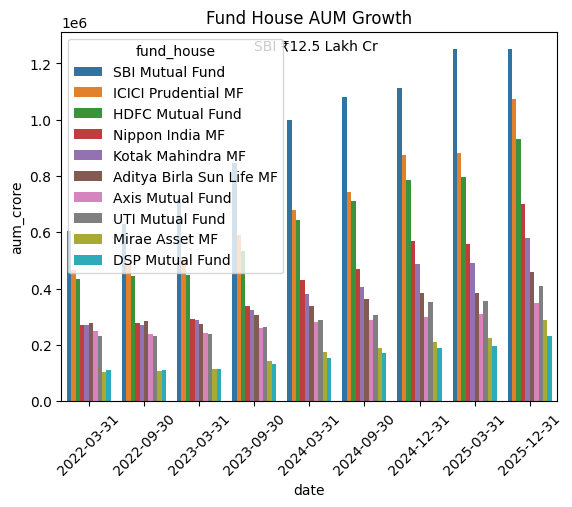

In [5]:
sns.barplot(
    data=aum_df,
    x="date",
    y="aum_crore",
    hue="fund_house"

)
plt.title("Fund House AUM Growth")
plt.xticks(rotation=45)
plt.text(
    x=3,
    y=1250000,
    s="SBI ₹12.5 Lakh Cr"
)

The Assets Under Management (AUM) of major fund houses exhibited consistent growth throughout the analysis period, reflecting increasing investor confidence and expanding participation in mutual fund investments. SBI Mutual Fund maintained the highest AUM among all fund houses, demonstrating its strong market presence and investor trust. The overall upward trend in AUM indicates sustained growth of the Indian mutual fund industry and rising adoption of systematic investment strategies

SIP Inflows Reached Record Levels

In [6]:
fig2=px.line(
    sip_df,
    x="month",
    y="sip_inflow_crore",

)
fig2.add_annotation(
    x="2025-12-01",
    y=31002,
    text="31,002 Cr Record High " 
)
fig2.show()

Monthly SIP inflows showed a consistent upward trajectory and achieved a record high towards the end of the study period.

Insight: Category-wise Net Inflow Analysis


<Axes: xlabel='month', ylabel='category'>

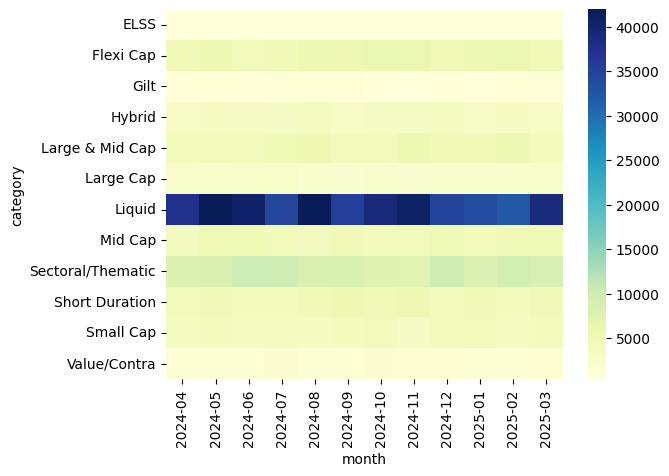

In [7]:
pivot=category_df.pivot_table(
    index="category",
    values="net_inflow_crore",
    columns="month"
)
sns.heatmap(
    pivot,
    cmap="YlGnBu"
)

The heatmap reveals significant variations in investor preference across mutual fund categories over time. Certain categories consistently attracted higher net inflows, indicating strong investor confidence and sustained demand. Periods of intensified colour suggest months with exceptional capital inflows, while lighter regions indicate relatively lower investment activity. The observed pattern highlights that investor allocation decisions are influenced by market conditions, risk appetite, and prevailing economic trends.

Investors Aged 31–45 Dominate SIP Investments

<Axes: ylabel='count'>

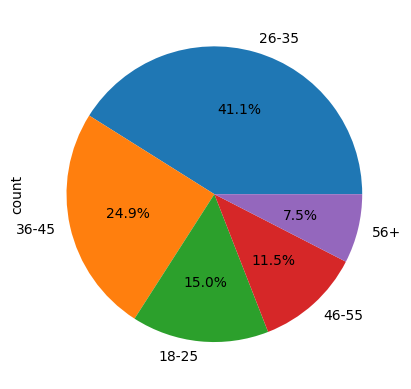

In [8]:
transaction_df["age_group"].value_counts().plot.pie(autopct="%1.1f%%")

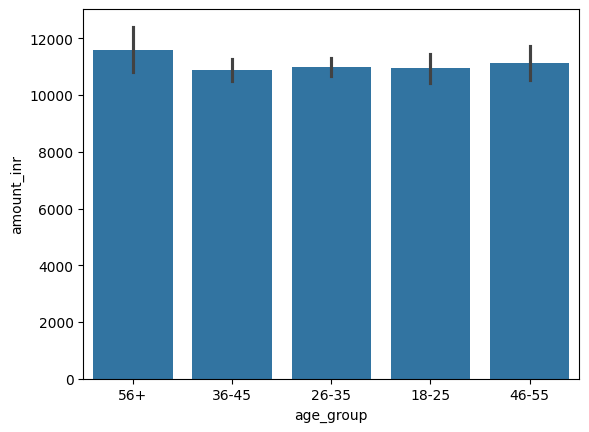

In [9]:
sip_amount_df=transaction_df[transaction_df["transaction_type"]=="SIP"]
sns.barplot(
    data=sip_amount_df,
    x="age_group",
    y="amount_inr"
)
plt.show()

<Axes: ylabel='count'>

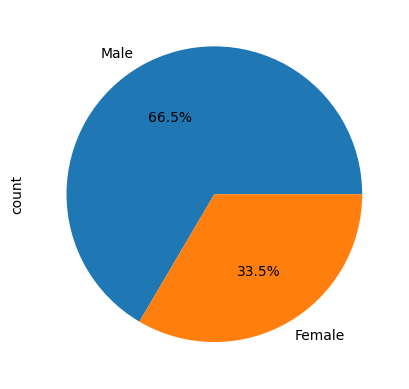

In [10]:
transaction_df["gender"].value_counts().plot.pie(autopct="%1.1f%%")

The largest share of SIP investments originated from investors in the middle-age group, highlighting their strong participation in wealth creation.

Geographic Concentration Exists

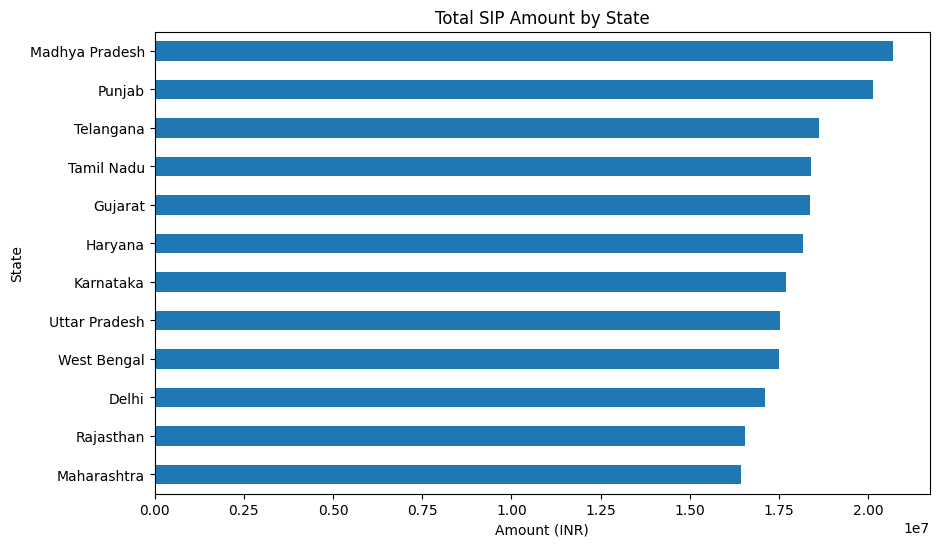

In [11]:
sip_amount_df.groupby("state")["amount_inr"]\
.sum()\
.sort_values()\
.plot.barh(figsize=(10,6))

plt.title("Total SIP Amount by State")
plt.xlabel("Amount (INR)")
plt.ylabel("State")
plt.show()

A significant proportion of SIP investments originated from Madhyapradesh, indicating geographical concentration in mutual fund adoption.

T30 Cities Continue to Lead Participation

<Axes: ylabel='count'>

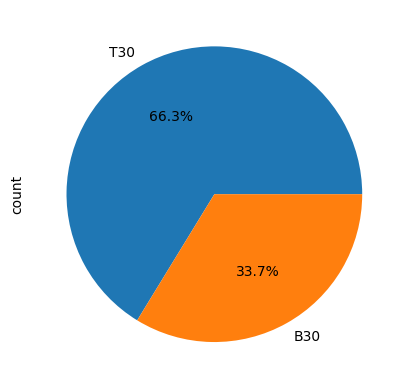

In [12]:
transaction_df["city_tier"].value_counts().plot.pie(autopct="%1.1f%%")

Investors from T30 cities contributed a larger share of investments compared to B30 cities.

Folio count growth 

In [16]:
fig3=px.line(
    folio_df,
    x="month",
    y="total_folios_crore"
)

fig3.add_annotation(
    x="2022-01-01",
    y=13.26,
    text="13.26 Cr"
)
fig3.add_annotation(
    x="2025-12-31",
    y=26.12,
    text="26.12 Cr"
)
fig3.show()

Mutual fund folio counts increased significantly from 2022 to 2025, demonstrating growing retail investor participation.

NAV return correlation matrix 

<Axes: xlabel='month', ylabel='month'>

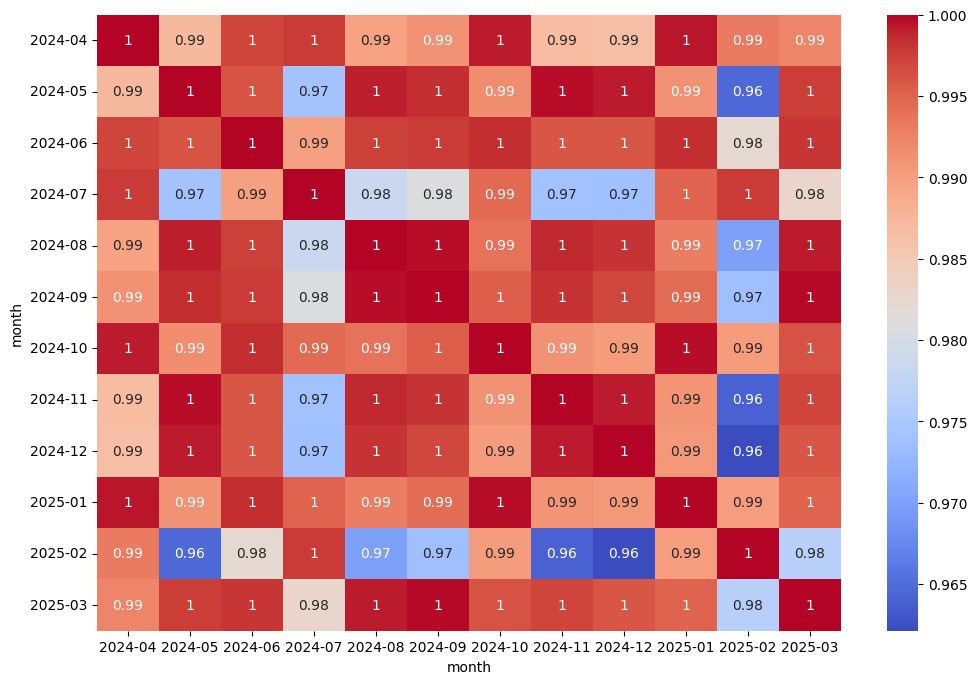

In [17]:
returns=pivot.pct_change()

corr_matrix=returns.corr()

plt.figure(figsize=(12,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

Most mutual fund schemes exhibited strong positive correlations, suggesting that market-wide factors influence overall fund performance.

Sector allocation donut

([<matplotlib.patches.Wedge at 0x222dff92d50>,
 [Text(1.0511775890460342, 0.32407665187015083, 'Automobile'),
  Text(0.39777925568734834, 1.025559195631739, 'Banking'),
  Text(-0.3561706519209926, 1.04074130633418, 'Cement'),
  Text(-0.5699716733669279, 0.9408146956544122, 'Consumer Goods'),
  Text(-0.8034899687247957, 0.7512681745945498, 'Diversified'),
  Text(-0.9723695797146933, 0.5142931075228122, 'Energy'),
  Text(-1.084904723791781, 0.1816087561057544, 'FMCG'),
  Text(-0.9823667126334691, -0.4949299363644428, 'IT'),
  Text(-0.5328540998438646, -0.9623234946106143, 'Infrastructure'),
  Text(-0.23800899175473364, -1.0739421398957651, 'NBFC'),
  Text(-0.02752662005674481, -1.0996555302403803, 'Paints'),
  Text(0.46304050682177883, -0.9977943119913194, 'Pharma'),
  Text(0.8918846566493009, -0.6438491742897234, 'Telecom'),
  Text(1.0670550798679053, -0.2671955398731393, 'Utilities')])

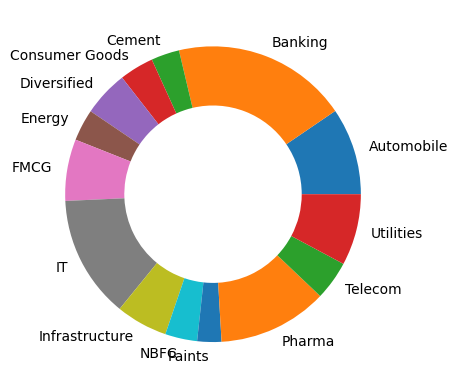

In [20]:
sector_weight=portfolio_df.groupby("sector")["weight_pct"].sum()
plt.pie(
    sector_weight,
    labels=sector_weight.index,
    wedgeprops={"width":0.4}
)

The sector allocation analysis indicates that Banking, Information Technology (IT), Pharma, and Automobile sectors constitute the largest share of mutual fund portfolios. This suggests that fund managers are primarily allocating capital toward sectors with strong growth potential and significant market capitalization. In contrast, sectors such as Cement, Paints, and Consumer Goods receive relatively lower allocations, reflecting a more selective investment approach. The diversification across multiple sectors helps reduce concentration risk while maintaining exposure to key drivers of economic growth.

Funds Category wise 5 yr return pct


Text(0, 0.5, 'Category')

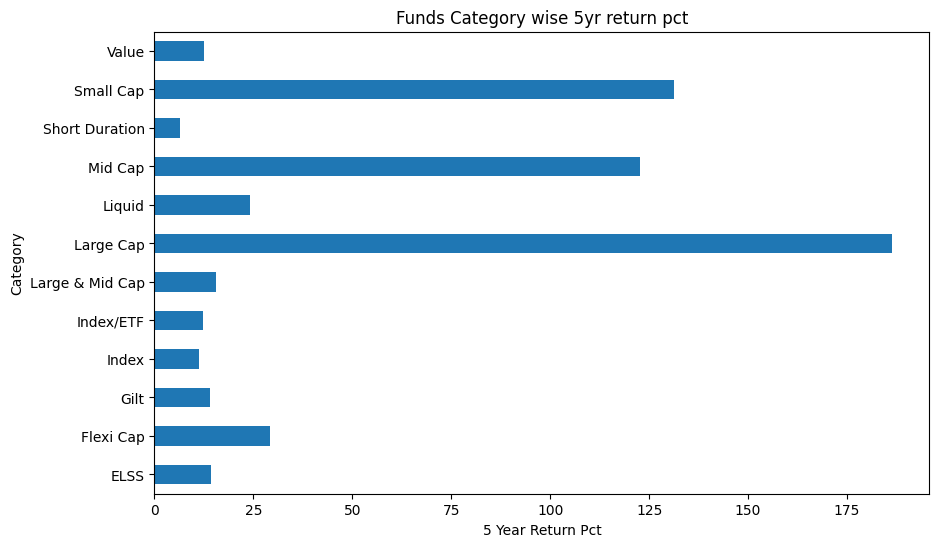

In [ ]:
performance_df.groupby("category")["return_5yr_pct"].sum().plot.barh(figsize=(10,6))

plt.title("Funds Category wise 5yr return pct")
plt.xlabel("5 Year Return Pct")
plt.ylabel("Category")


Large Cap funds delivered the highest 5-year returns among all mutual fund categories, followed by Small Cap and Mid Cap funds. Equity-oriented categories significantly outperformed debt-oriented categories such as Liquid, Short Duration, and Gilt funds, highlighting the superior long-term wealth creation potential of equity investments. The results indicate that investors willing to tolerate higher market risk were rewarded with substantially higher returns over the analysis period.

Risk Grade Distribution

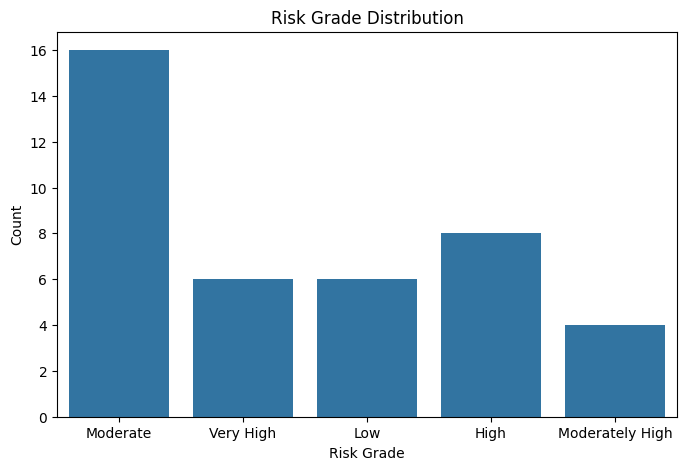

In [31]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=performance_df,
    x="risk_grade"
)

plt.title("Risk Grade Distribution")
plt.xlabel("Risk Grade")
plt.ylabel("Count")
plt.show()

The majority of mutual fund schemes fall within the Moderate and High risk categories, indicating that fund offerings are primarily designed for investors seeking a balance between risk and return. Comparatively fewer schemes are classified as Low Risk or Moderately High Risk, suggesting that the mutual fund industry is largely focused on growth-oriented investment strategies. This distribution highlights the increasing preference for products that offer higher return potential while maintaining manageable levels of risk.

Category-wise Fund Count

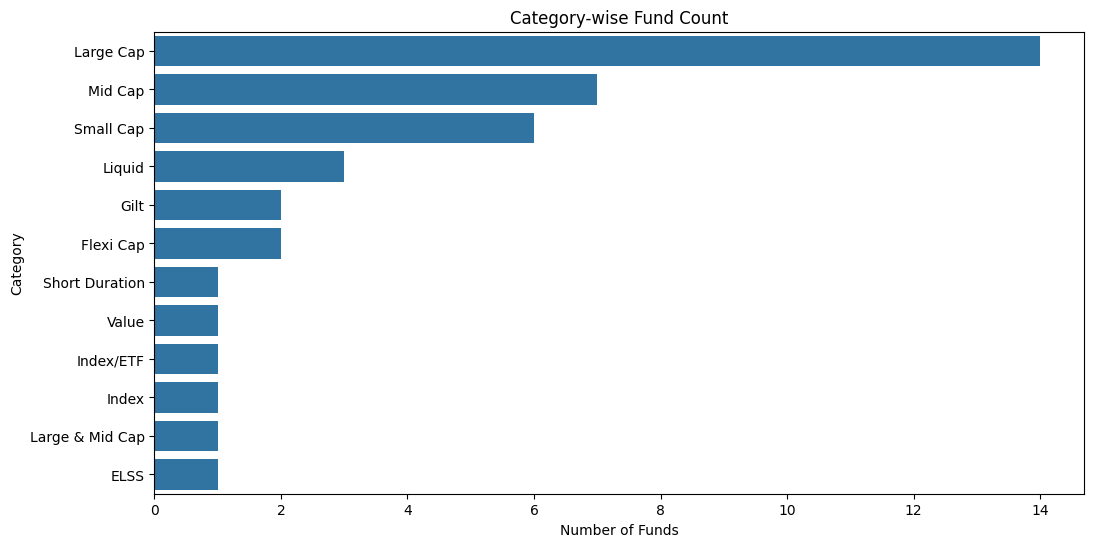

In [32]:
cat_count = (
    performance_df["category"]
    .value_counts()
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=cat_count.values,
    y=cat_count.index
)

plt.title("Category-wise Fund Count")
plt.xlabel("Number of Funds")
plt.ylabel("Category")
plt.show()

Large Cap funds represent the largest category within the analyzed mutual fund universe, followed by Mid Cap and Small Cap funds. This distribution indicates a strong preference among fund houses for offering equity-oriented investment products that cater to long-term wealth creation objectives. The relatively lower number of debt, index, and specialized fund categories suggests that the mutual fund industry remains predominantly focused on equity-based investment strategies.

Fund House Market Share

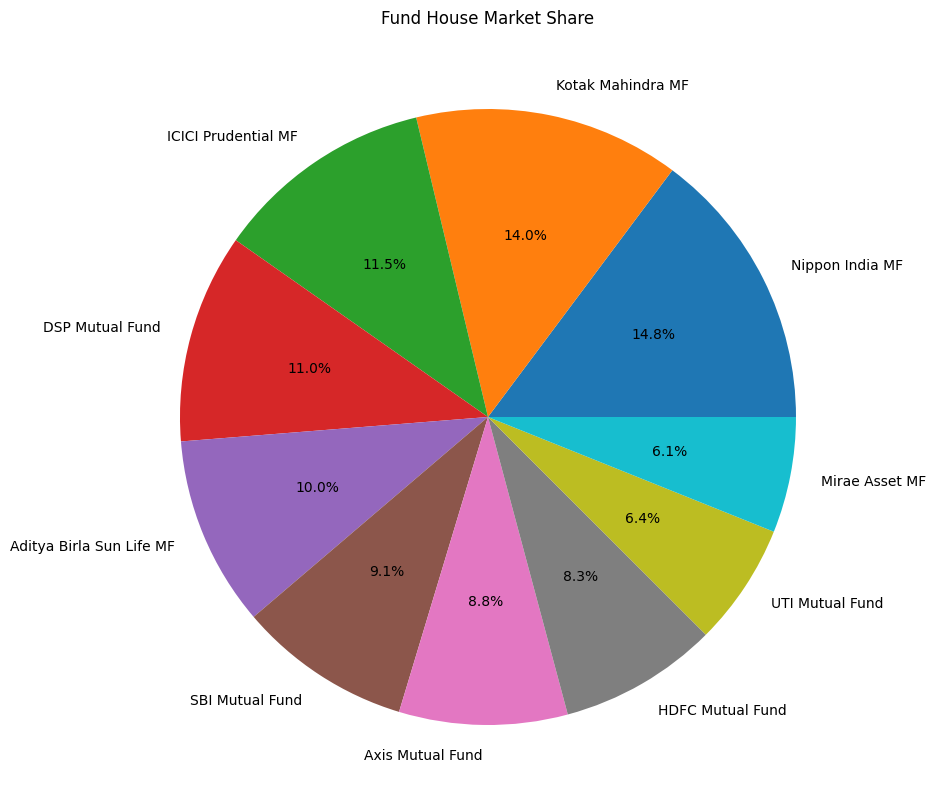

In [33]:
market_share = (
    performance_df
    .groupby("fund_house")["aum_crore"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,10))

plt.pie(
    market_share,
    labels=market_share.index,
    autopct="%1.1f%%"
)

plt.title("Fund House Market Share")
plt.show()

The mutual fund industry exhibits a moderately concentrated market structure, with a few leading fund houses accounting for a significant share of total assets. Nippon India Mutual Fund emerged as the largest contributor, followed closely by Kotak Mahindra Mutual Fund and ICICI Prudential Mutual Fund. The combined market share of the top fund houses highlights their strong brand recognition, extensive distribution networks, and consistent investment performance. This concentration indicates that investors tend to prefer established fund houses with proven track records and large-scale asset management capabilities.

Monthly Net Inflow Trend

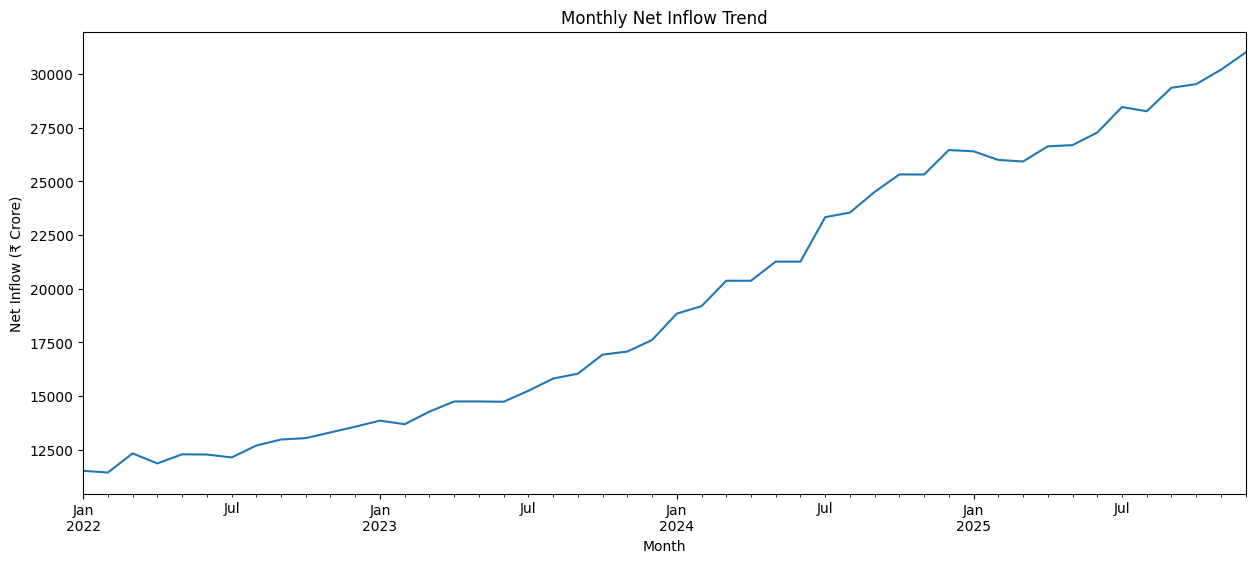

In [35]:
sip_df["month"] = pd.to_datetime(
    sip_df["month"]
)

monthly = (
    sip_df.groupby(
        sip_df["month"].dt.to_period("M")
    )["sip_inflow_crore"]
    .sum()
)

plt.figure(figsize=(15,6))

monthly.plot()

plt.title("Monthly Net Inflow Trend")
plt.ylabel("Net Inflow (₹ Crore)")
plt.xlabel("Month")

plt.show()

Monthly net inflows exhibited a strong and consistent upward trend throughout the analysis period, increasing from approximately ₹11,500 crore in early 2022 to over ₹31,000 crore by the end of 2025. The sharp acceleration observed during 2024 and 2025 reflects growing investor confidence, rising participation in mutual funds, and increasing adoption of systematic investment plans (SIPs). The absence of significant long-term declines indicates the resilience of investor sentiment despite changing market conditions.

# Conclusion

The exploratory data analysis provided valuable insights into the performance, growth, and investor participation trends within the Indian mutual fund industry from 2022 to 2025. The analysis revealed consistent growth in NAV values, Assets Under Management (AUM), SIP inflows, and folio counts, indicating increasing investor confidence and broader adoption of mutual fund investments.

Large Cap, Mid Cap, and Small Cap funds emerged as the dominant categories, with equity-oriented schemes delivering significantly higher long-term returns compared to debt-oriented funds. Fund house analysis showed that a small group of leading asset management companies controlled a substantial share of industry assets, highlighting a concentrated market structure.

Investor demographic and geographic analyses demonstrated that the 31–45 age group and T30 cities contribute the largest share of mutual fund investments. At the same time, growing participation from B30 cities reflects the expanding reach of financial products across India.

Portfolio allocation analysis indicated a strong preference for sectors such as Banking, Information Technology, Pharma, and Automobile, while the correlation analysis showed that most equity funds move together in response to market-wide factors. The steady rise in monthly net inflows and folio counts further confirms the increasing popularity of mutual funds as a long-term wealth creation vehicle.

Overall, the findings suggest that the Indian mutual fund industry is experiencing sustained growth, supported by rising retail participation, strong equity market performance, and increasing awareness of systematic investment strategies. These insights provide a strong foundation for the next phase of the project, which focuses on performance analytics, risk measurement, and advanced investment analysis.